In [1]:
import numpy as np 
import os
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from dip.models import *
from dip.utils.denoising_utils import *
import seaborn as sns
from skimage.io import imread
from torch.autograd import Variable
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, v_measure_score
import pickle

## Load Data

In [2]:
path = r"data/"
X = imread(path+'synthetic_image_gaussian_0.05.bmp')
img = imread(path+'synthetic_image_ture.bmp')

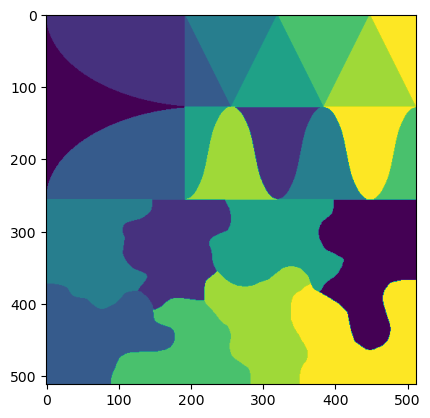

In [3]:
plt.imshow(img)

## GMM

In [4]:
def gmm_multiband(
    bands,
    n_components=3,
    covariance_type="full",
    random_state=0,
    missing_value=-9999,
    sort_by="mean",
    sort_feature=None,
    return_mapping=False,
):
    """
    Fit a Gaussian Mixture Model (GMM) on multiple 2D bands (same HxW shape),
    handling missing values and returning spatially reconstructed results.

    Parameters
    ----------
    bands : list of np.ndarray
        List of 2D arrays (H, W) with identical shapes.
    n_components : int
        Number of mixture components.
    covariance_type : str
        Covariance type for sklearn.mixture.GaussianMixture.
    random_state : int or None
        Random seed for reproducibility.
    missing_value : int or float
        Sentinel value to treat as missing (converted to NaN).
    sort_by : {"mean", "feature"}
        - "mean": sort components by the mean across all features.
        - "feature": sort components by a specific feature mean (requires sort_feature).
    sort_feature : int or None
        Feature index (0-based) used when sort_by="feature".
    return_mapping : bool
        If True, also returns {old_index: new_index}.

    Returns
    -------
    labels_2d : np.ndarray
        (H, W) float array with reordered labels, NaN where invalid.
    probas_3d : np.ndarray
        (H, W, K) float array with reordered responsibilities, NaN where invalid.
    mask : np.ndarray
        (H, W) boolean array of valid pixels.
    gmm : GaussianMixture
        Fitted model with parameters reordered.
    mapping : dict (optional)
        Mapping {old_idx -> new_idx}.
    """
    # 0) checks
    if len(bands) < 1:
        raise ValueError("Provide at least one 2D band.")
    h, w = bands[0].shape
    if not all(b.shape == (h, w) for b in bands):
        raise ValueError("All bands must have the same shape (H, W).")

    # 1) clean + valid mask (finite across all bands)
    clean = [np.asarray(b, dtype=float) for b in bands]
    if missing_value is not None:
        clean = [np.where(b == missing_value, np.nan, b) for b in clean]

    mask = np.isfinite(clean[0])
    for b in clean[1:]:
        mask &= np.isfinite(b)

    if not np.any(mask):
        raise ValueError("No valid pixels across all bands.")

    # 2) feature matrix X: (n_valid, n_bands)
    X = np.column_stack([b[mask] for b in clean])

    # 3) fit GMM
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        random_state=random_state,
    ).fit(X)

    labels = gmm.predict(X)          # (n_valid,)
    probas = gmm.predict_proba(X)    # (n_valid, K)

    # 4) component sorting
    if sort_by == "mean":
        scores = gmm.means_.mean(axis=1)
    elif sort_by == "feature":
        if sort_feature is None:
            raise ValueError("sort_feature must be provided when sort_by='feature'.")
        if not (0 <= sort_feature < gmm.means_.shape[1]):
            raise ValueError("sort_feature is out of range for the number of bands.")
        scores = gmm.means_[:, sort_feature]
    else:
        raise ValueError("sort_by must be either 'mean' or 'feature'.")

    order = np.argsort(scores, kind="mergesort")  # stable ascending order
    inv_order = np.empty_like(order)
    inv_order[order] = np.arange(order.size)
    mapping = {int(old): int(new) for new, old in enumerate(order)}

    # Apply reordering to outputs
    labels = inv_order[labels]
    probas = probas[:, order]

    # Reorder model parameters consistently
    gmm.means_ = gmm.means_[order]
    gmm.weights_ = gmm.weights_[order]

    # covariances_ exists for all covariance types; shape depends on type
    if hasattr(gmm, "covariances_") and gmm.covariance_type != "tied":
        gmm.covariances_ = gmm.covariances_[order]

    # precisions / cholesky are not indexed for "tied"
    if hasattr(gmm, "precisions_") and gmm.covariance_type != "tied":
        gmm.precisions_ = gmm.precisions_[order]
    if hasattr(gmm, "precisions_cholesky_") and gmm.covariance_type != "tied":
        gmm.precisions_cholesky_ = gmm.precisions_cholesky_[order]

    # 5) reconstruct 2D / 3D without Python loops over pixels
    labels_2d = np.full((h, w), np.nan, dtype=float)
    labels_2d[mask] = labels.astype(float)

    K = probas.shape[1]
    probas_3d = np.full((h, w, K), np.nan, dtype=float)
    probas_3d[mask, :] = probas  # advanced indexing fills valid pixels for all K

    if return_mapping:
        return labels_2d, probas_3d, mask, gmm, mapping
    return labels_2d, probas_3d, mask, gmm


In [5]:
label,prob,mask,gmm = gmm_multibandes([X],8)

In [6]:
real,_,_,_ = gmm_multibandes([img],8)

In [8]:
adjusted_rand_score(label.flatten(),img.flatten())

0.2897320460813672

In [9]:
normalized_mutual_info_score(label.flatten(),img.flatten())

0.47285505662923505

In [7]:
class EarlyStop():
    def __init__(self, size, patience):
        self.patience = patience
        self.wait_count = 0
        self.best_score = float('inf')
        self.best_epoch = 0
        self.img_collection = []
        self.stop = False
        self.size = size

    def check_stop(self, current, cur_epoch):
      #stop when variance doesn't decrease for consecutive P(patience) times
        if current < self.best_score:
            self.best_score = current
            self.best_epoch = cur_epoch
            self.wait_count = 0
            should_stop = False
        else:
            self.wait_count += 1
            should_stop = self.wait_count >= self.patience
        return should_stop

    def update_img_collection(self, cur_img):
        self.img_collection.append(cur_img)
        if len(self.img_collection) > self.size:
            self.img_collection.pop(0)

    def get_img_collection(self):
        return self.img_collection

def myMetric(x1, x2):
    return ((x1 - x2) ** 2).sum() / x1.size

In [8]:
prob.shape

(512, 512, 8)

In [9]:
def closure(iterator):
    #DIP
    net_input_perturbed = net_input + torch.zeros_like(net_input).normal_(std=reg_noise_std)
    
    r_img_torch = net(net_input_perturbed)
    total_loss = criterion(r_img_torch, img_noisy_torch)
    total_loss.backward()
    loss_history.append(total_loss.item())
    if iterator % show_every == 0:
        # evaluate recovered image (ARI)
        r_img_np = torch_to_np(r_img_torch)
        res_map = (np.argmax(r_img_np[:,:,:],axis=0))
        l_res.append(r_img_np)
        ari = round(adjusted_rand_score(real.flatten(),res_map.flatten()),4)
        l_ari.append(ari)
    

        #variance hisotry
        r_img_np = (r_img_np).reshape(-1)
        earlystop.update_img_collection(r_img_np)
        img_collection = earlystop.get_img_collection()
        if len(img_collection) == buffer_size:
            ave_img = np.mean(img_collection,axis = 0)
            variance = []
            for tmp in img_collection:
                variance.append(myMetric(ave_img, tmp))
            cur_var = np.mean(variance)
            cur_epoch = iterator
            variance_history.append(cur_var)
            x_axis.append(cur_epoch)
            if earlystop.stop == False:
                earlystop.stop = earlystop.check_stop(cur_var, cur_epoch)
    return total_loss

In [12]:
res_dip = {}
n_realization = 30  

# Backend / determinism knobs (keep minimal, paper-friendly)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

# Hyperparameters
buffer_size = 100
patience = 30
lr = 1e-2
optimizer_name = "adam"  # {"adam", "sgd"}
num_iter = 1000
use_l1 = False

input_depth = 8
n_channels = 8
width = 64
skip_n33d = width
skip_n33u = width
skip_n11 = 5
num_scales = 5
reg_noise_std = 1.0 / 30.0

# Data: prob assumed (H, W, K)
img_noisy_np = np.transpose(prob, (2, 0, 1))  # (K, H, W)
img_noisy_torch = np_to_torch(img_noisy_np).to(device=device, dtype=dtype)
H, W = img_noisy_np.shape[1], img_noisy_np.shape[2]

# Network
net = skip_gmm(
    input_depth,
    n_channels,
    num_channels_down=[skip_n33d] * num_scales,
    num_channels_up=[skip_n33u] * num_scales,
    num_channels_skip=[skip_n11] * num_scales,
    upsample_mode="nearest",
    downsample_mode="stride",
    need_bias=True,
    pad="reflection",
    act_fun="LeakyReLU",
    last_activation="softmax",
).to(device=device, dtype=dtype)

# Loss
criterion = (torch.nn.L1Loss if use_l1 else torch.nn.MSELoss)().to(device)


for run_idx in range(n_realization):
    print(run_idx, end="-")
    net_input = get_noise(input_depth, "noise", (H, W)).to(device=device, dtype=dtype).detach()

    params = get_params("net", net, net_input)
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(params, lr=lr)
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(params, lr=lr)
    else:
        raise ValueError("optimizer_name must be 'adam' or 'sgd'.")

    # Histories (closure is assumed to append to these)
    loss_history = []
    dice_history = []
    dice_mean_history = []
    variance_history = []
    x_axis = []
    l_r_img = []
    l_res = []
    l_ari = []

    earlystop = EarlyStop(size=buffer_size, patience=patience)

    res_dip[run_idx] = {}

    for it in range(num_iter):
        optimizer.zero_grad(set_to_none=True)
        closure(it)  # expected to compute loss and call backward internally
        optimizer.step()
       

    best_epoch = earlystop.best_epoch
    res_dip[run_idx]["earlystop"] = best_epoch
    res_dip[run_idx]["l_ari"] = l_ari
    res_dip[run_idx]["x_axis"] = x_axis
    res_dip[run_idx]["variance_history"] = variance_history
    res_dip[run_idx]["res_map"] = l_res[best_epoch]



0-1-2-3-

KeyboardInterrupt: 

In [ ]:
IDS = range(0, 30)          # runs to aggregate
EPS = 1e-12
OUT_DIR = os.path.join("fig", "combination", "ANISO_DATA")
os.makedirs(OUT_DIR, exist_ok=True)

# 'label' must be a 2D numpy array (H, W) with integer class labels.
if 'label' not in globals():
    raise ValueError("Variable 'label' is not defined. Please provide the ground-truth 2D label array.")
if not isinstance(label, np.ndarray) or label.ndim != 2:
    raise ValueError("'label' must be a 2D numpy array (H, W) with integer class labels.")

# ----------------------
# Collect res_maps
# ----------------------
res_maps = []   # list of arrays, each (K, H, W)
shape_ref = None

for i in IDS:
    entry = res_dip.get(i)
    if not isinstance(entry, dict):
        continue
    rm = entry.get('res_map', None)
    if rm is None or not isinstance(rm, np.ndarray) or rm.ndim != 3:
        continue

    if shape_ref is None:
        shape_ref = rm.shape  # (K, H, W)
    if rm.shape != shape_ref:
        # skip inconsistent shapes
        continue

    res_maps.append(rm)

if len(res_maps) == 0:
    raise ValueError("No valid res_map found across the specified IDs.")

M = len(res_maps)
K, H, W = shape_ref

if label.shape != (H, W):
    raise ValueError(f"'label' shape {label.shape} does not match res_map spatial size {(H, W)}.")

# ----------------------
# Stack and per-pixel normalization
# ----------------------
stack = np.stack(res_maps, axis=0)                 # (M, K, H, W)
den = np.sum(stack, axis=1, keepdims=True) + EPS   # sum over classes per pixel
stack = stack / den                                # ensure probs sum to 1 per pixel

# ----------------------
# Combination methods
# ----------------------
# 1) Mean
p_mean = np.mean(stack, axis=0)                           # (K, H, W)
p_mean /= (np.sum(p_mean, axis=0, keepdims=True) + EPS)
lbl_mean = np.argmax(p_mean, axis=0)                      # (H, W)

# 2) Majority vote on per-run argmax labels
lbl_runs = np.argmax(stack, axis=1)                       # (M, H, W)
counts = np.zeros((K, H, W), dtype=np.int32)
rows = np.arange(H)[:, None]
cols = np.arange(W)[None, :]
for m in range(M):
    np.add.at(counts, (lbl_runs[m], rows, cols), 1)
lbl_vote = np.argmax(counts, axis=0)

# ----------------------
# Compute ARI & NMI vs label
# ----------------------
gt = label.ravel()

def metrics_vs_gt(pred_2d):
    pred = pred_2d.ravel()
    ari = adjusted_rand_score(gt, pred)
    nmi = normalized_mutual_info_score(gt, pred)  # average_method='arithmetic' by default
    return ari, nmi

ari_mean, nmi_mean   = metrics_vs_gt(lbl_mean)
ari_vote, nmi_vote   = metrics_vs_gt(lbl_vote)

print("Metrics vs label (Adjusted Rand Index, Normalized Mutual Information):")
print(f" - Mean: ARI={ari_mean:.6f} | NMI={nmi_mean:.6f}")
print(f" - Majority vote: ARI={ari_vote:.6f} | NMI={nmi_vote:.6f}")

# ----------------------
# Save (Label | Result) pairs for each method (gray colormap)
# ----------------------
pairs = [
    ("Mean", lbl_mean, ari_mean, nmi_mean, "argmax_mean_pair.png"),
    ("Majority Vote (labels)", lbl_vote, ari_vote, nmi_vote, "argmax_vote_pair.png"),
]

for title, pred, ari, nmi, fname in pairs:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    # Left: Label (GT)
    axes[0].imshow(label, cmap='gray')
    axes[0].set_title("Label (GT)")
    axes[0].axis('off')
    # Right: Result
    axes[1].imshow(pred, cmap='gray')
    axes[1].set_title(f"{title}\nARI={ari:.4f} | NMI={nmi:.4f}")
    axes[1].axis('off')
    plt.tight_layout()
    path = os.path.join(OUT_DIR, fname)
    plt.savefig(path, dpi=150)
    plt.close()

# ----------------------
# Also save a 2x2 grid (Label | Result) for all methods together
# ----------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
methods = [
    ("Mean", lbl_mean, ari_mean, nmi_mean),
    ("Majority Vote (labels)", lbl_vote, ari_vote, nmi_vote),
]
for r, (title, pred, ari, nmi) in enumerate(methods):
    axes[r, 0].imshow(label, cmap='gray')
    axes[r, 0].set_title("Label (GT)")
    axes[r, 0].axis('off')

    axes[r, 1].imshow(pred, cmap='gray')
    axes[r, 1].set_title(f"{title} — ARI={ari:.4f} | NMI={nmi:.4f}")
    axes[r, 1].axis('off')

plt.tight_layout()
joint_path = os.path.join(OUT_DIR, "argmax_pairs_all.png")
plt.savefig(joint_path, dpi=150)
plt.close()

print(f"Saved pair figures and joint grid in: {OUT_DIR}")
